# 실습 9: 혼동행렬과 분류 결과 리포트
- 상황: 정확도 하나로는 어느 모델이 나은지 답할 수 없다
- 목표: 틀린 것을 두 종류로 나눠 보고, 오늘 결과를 리포트 한 장으로 마감한다

## Step 0. 앞 실습까지 재현하기

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("../../day02/lab06_clean-dataset/results/secom_clean.csv")

sensor_cols = [c for c in df.columns if c.startswith("sensor_")]
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].median())

df["불량여부"] = (df["result"] == "불량").astype(int)

X = df[sensor_cols]
y = df["불량여부"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

스케일러 = StandardScaler()
X_train_스케일 = 스케일러.fit_transform(X_train)
X_test_스케일 = 스케일러.transform(X_test)

로지스틱모델 = LogisticRegression()
로지스틱모델.fit(X_train_스케일, y_train)

예측 = 로지스틱모델.predict(X_test_스케일)

print("학습용:", X_train.shape[0], "건")
print("시험용:", X_test.shape[0], "건")
print("정확도:", round(accuracy_score(y_test, 예측) * 100, 2), "%")


학습용: 1253 건
시험용: 314 건
정확도: 92.99 %


## Step 1. 오늘 쓸 말 정리하기

### 용어 풀이 - 결과를 네 칸으로 나눠 볼 때 쓰는 말

| 말 | 뜻 |
|---|---|
| 혼동행렬 | 맞힌 것과 틀린 것을 네 칸으로 나눠 놓은 표 |
| 놓친 불량 | 불량인데 양품이라 한 것. 걸러지지 않고 고객에게 간다 |
| 헛경보 | 양품인데 불량이라 한 것. 멀쩡한 것을 세워 다시 본다 |
| 재현율 (recall) | 실제 불량 중 몇 %를 잡았나 |
| 정밀도 (precision) | 불량이라 한 것 중 진짜가 몇 %였나 |
| F1 | 재현율과 정밀도를 함께 보는 값. 한쪽만 좋으면 오르지 않는다 |

## Step 2. 네 칸으로 쪼개기

In [2]:
# confusion_matrix - 실제 답과 예측을 맞대어 네 칸으로 세어준다
from sklearn.metrics import confusion_matrix

행렬 = confusion_matrix(y_test, 예측)
print(행렬)

# ravel() - 네 칸을 한 줄로 펴서 하나씩 이름을 붙여 받는다
# 순서가 정해져 있다: 왼쪽위, 오른쪽위, 왼쪽아래, 오른쪽아래
맞힌양품, 헛경보, 놓친불량, 잡은불량 = 행렬.ravel()

print("양품인데 양품이라 함 :", 맞힌양품)
print("양품인데 불량이라 함 :", 헛경보,   " <- 헛경보")
print("불량인데 양품이라 함 :", 놓친불량, " <- 놓친 불량")
print("불량인데 불량이라 함 :", 잡은불량)


[[291   2]
 [ 20   1]]
양품인데 양품이라 함 : 291
양품인데 불량이라 함 : 2  <- 헛경보
불량인데 양품이라 함 : 20  <- 놓친 불량
불량인데 불량이라 함 : 1


## Step 3. 네 칸이 현장에서 무슨 상황인가

| 칸 | 내 숫자 | 현장에서는 |
|---|---|---|
| 양품인데 양품 | [293] | 아무 일 없음 |
| 양품인데 불량 (헛경보) | [0] | 멀쩡한 걸 세우고 다시 본다. 사람 손이 든다 |
| 불량인데 양품 (놓친 불량) | [19] | 걸러지지 않고 고객에게 간다 |
| 불량인데 불량 | [2] | 원하던 것. 미리 잡았다 |

## Step 4. 두 지표를 손으로 계산하기

In [3]:
# 재현율 - 실제 불량 중 몇 %를 잡았나
# 분모는 "실제 불량 전체" = 잡은 것 + 놓친 것
재현율 = 잡은불량 / (잡은불량 + 놓친불량)

# 정밀도 - 불량이라 한 것 중 진짜가 몇 %였나
# 분모는 "불량이라고 한 것 전체" = 진짜 + 헛경보
정밀도 = 잡은불량 / (잡은불량 + 헛경보)

print("재현율:", round(재현율, 3), " <- 실제 불량", 잡은불량 + 놓친불량, "건 중", 잡은불량, "건")
print("정밀도:", round(정밀도, 3), " <- 불량이라 한", 잡은불량 + 헛경보, "건 중", 잡은불량, "건")


재현율: 0.048  <- 실제 불량 21 건 중 1 건
정밀도: 0.333  <- 불량이라 한 3 건 중 1 건


### 문법 노트 - 네 칸에서 지표 뽑기

| 쓴 것 | 하는 일 | 왜 여기 쓰나 |
|---|---|---|
| confusion_matrix(실제, 예측) | 맞고 틀림을 네 칸으로 세어준다 | 정확도 하나로는 안 보이는 걸 본다 |
| .ravel() | 네 칸을 한 줄로 펴준다 | 칸마다 이름을 붙여 받으려고 |
| classification_report | 지표를 한 번에 계산해 표로 보여준다 | 손으로 구한 값과 맞춰보려고 |

**분자는 둘 다 같고 분모가 다르다.**<br>
재현율 = 잡은불량 / (잡은불량 + 놓친불량)   분모가 "실제 불량 전체"<br>
정밀도 = 잡은불량 / (잡은불량 + 헛경보)     분모가 "불량이라 한 것 전체"<br>
헷갈리면 분모부터 정하면 된다.

## Step 5. 라이브러리 출력과 대조하기

In [4]:
from sklearn.metrics import classification_report

# target_names - 0과 1 대신 사람이 읽을 이름을 붙인다
# digits=3 - 소수점 셋째 자리까지
print(classification_report(y_test, 예측,
                            target_names=["양품", "불량"], digits=3))


              precision    recall  f1-score   support

          양품      0.936     0.993     0.964       293
          불량      0.333     0.048     0.083        21

    accuracy                          0.930       314
   macro avg      0.635     0.520     0.523       314
weighted avg      0.895     0.930     0.905       314



## Step 6. 기준 모델의 재현율은 얼마인가

In [5]:
import numpy as np
import warnings
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# 기준 모델: 전부 양품(0)이라 답한다 (학습 없음)
기준예측 = np.zeros(len(y_test), dtype=int)

def 지표계산(예측배열, 이름):
    정확도 = (예측배열 == y_test).mean()
    행렬 = confusion_matrix(y_test, 예측배열)
    _, 헛경보, 놓친불량, 잡은불량 = 행렬.ravel()
    # zero_division=0 - 분모가 0이 되는 경우(불량이라 한 것이 0건) 정밀도를 0으로 처리
    재현율 = recall_score(y_test, 예측배열, zero_division=0)
    정밀도 = precision_score(y_test, 예측배열, zero_division=0)
    F1 = f1_score(y_test, 예측배열, zero_division=0)
    return {
        "모델": 이름,
        "정확도": round(정확도, 3),
        "재현율": round(재현율, 3),
        "정밀도": round(정밀도, 3),
        "F1": round(F1, 3),
        "놓친 불량": int(놓친불량),
        "헛경보": int(헛경보),
    }

비교표_기준vs학습 = pd.DataFrame([
    지표계산(기준예측, "전부 양품 (기준 모델)"),
    지표계산(예측, "학습시킨 로지스틱 회귀"),
])
print(비교표_기준vs학습)

# zero_division 옵션 없이 계산하면 실제로 뜨는 경고 문구를 그대로 확인
print()
with warnings.catch_warnings(record=True) as 경고목록:
    warnings.simplefilter("always")
    precision_score(y_test, 기준예측)  # zero_division 지정 없음
    if 경고목록:
        print("실제 뜨는 경고:", str(경고목록[0].message))


              모델    정확도    재현율    정밀도     F1  놓친 불량  헛경보
0  전부 양품 (기준 모델)  0.933  0.000  0.000  0.000     21    0
1   학습시킨 로지스틱 회귀  0.930  0.048  0.333  0.083     20    2

실제 뜨는 경고: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.


### 기준 모델 vs 학습시킨 모델 비교

| 모델 | 정확도 | 재현율 | 정밀도 | F1 | 놓친 불량 | 헛경보 |
|---|---|---|---|---|---|---|
| 전부 양품 (기준 모델) | 0.933 | 0.000 | 0.000 | 0.000 | 21 | 0 |
| 학습시킨 로지스틱 회귀 | 0.933 | 0.048 | 0.333 | 0.083 | 20 | 2 |

**경고가 뜨는 이유** (실제 문구: *Precision is ill-defined and being set to 0.0 due to no predicted samples.*)

— 정밀도는 "불량이라고 예측한 것 중" 맞은 비율인데, 기준 모델은 불량이라고 예측한 게 0건이라 분모가 0이 되어 정의할 수 없기 때문입니다.


— 정확도만 보면 기준 모델(0.933)이 학습 모델(0.930)보다 오히려 근소하게 높지만, 재현율·정밀도·F1은 모두 학습 모델이 앞서고 놓친 불량도 21건 → 20건으로 1건 줄었습니다 — 다만 그 대가로 헛경보가 0건 → 2건 생겼습니다.

## Step 7. 문턱을 낮춰 더 잡아보기

In [6]:
# 모델을 다시 학습시키지 않고, 이미 학습된 로지스틱모델의 확률 출력만 이용한다
# predict_proba의 두 번째 열이 "불량(1)일 가능성"
불량확률 = 로지스틱모델.predict_proba(X_test_스케일)[:, 1]

문턱목록 = [0.5, 0.3, 0.2, 0.1]
문턱결과목록 = []

for 문턱 in 문턱목록:
    # 예측은 건드리지 않고, 문턱마다 새로 계산한 예측을 임시로만 쓴다
    문턱예측 = (불량확률 >= 문턱).astype(int)

    행렬 = confusion_matrix(y_test, 문턱예측)
    _, 헛경보_t, 놓친불량_t, 잡은불량_t = 행렬.ravel()
    재현율_t = recall_score(y_test, 문턱예측, zero_division=0)
    정밀도_t = precision_score(y_test, 문턱예측, zero_division=0)

    문턱결과목록.append({
        "문턱": 문턱,
        "잡은 불량": int(잡은불량_t),
        "놓친 불량": int(놓친불량_t),
        "헛경보": int(헛경보_t),
        "재현율": round(재현율_t, 3),
        "정밀도": round(정밀도_t, 3),
    })

문턱비교표 = pd.DataFrame(문턱결과목록)
문턱비교표


,문턱,잡은 불량,놓친 불량,헛경보,재현율,정밀도
0,0.5,1,20,2,0.048,0.333
1,0.3,4,17,5,0.190,0.444
2,0.2,4,17,18,0.190,0.182
3,0.1,9,12,41,0.429,0.180


## Step 8. 분류 결과 리포트 마감하기

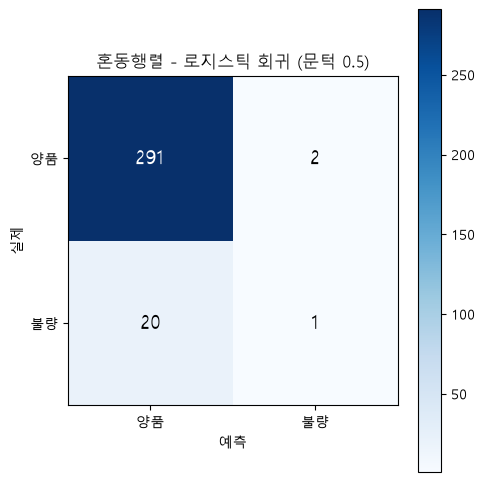

그림 저장 위치: C:\Users\정유진\Desktop\secom-project\day03\lab09_confusion-matrix\results\confusion_matrix.png

리포트 저장 위치: C:\Users\정유진\Desktop\secom-project\day03\lab09_confusion-matrix\results\report.md

# 분류 결과 리포트

## 1. 데이터
- 정제본 행 수: 1567
- 정제본 열 수: 52
- 불량 비율: 6.64%
- 학습용 건수: 1253
- 시험용 건수: 314

## 2. 모델
- 모델: 로지스틱 회귀 (LogisticRegression, 기본 설정)
- 함께 넣은 처리: StandardScaler로 표준화 (학습용 기준으로 fit, 학습용/시험용 모두 transform)

## 3. 결과 표 (기준 모델 vs 학습 모델)

| 모델 | 정확도 | 재현율 | 정밀도 | F1 | 놓친 불량 | 헛경보 |
|---|---|---|---|---|---|---|
| 전부 양품 (기준 모델) | 0.933 | 0.0 | 0.0 | 0.0 | 21 | 0 |
| 학습시킨 로지스틱 회귀 | 0.93 | 0.048 | 0.333 | 0.083 | 20 | 2 |

## 4. 혼동행렬 (문턱 0.5)
- 양품인데 양품: 291
- 양품인데 불량 (헛경보): 2
- 불량인데 양품 (놓친 불량): 20
- 불량인데 불량 (잡은 불량): 1

## 5. 문턱별 비교표

| 문턱 | 잡은 불량 | 놓친 불량 | 헛경보 | 재현율 | 정밀도 |
|---|---|---|---|---|---|
| 0.5 | 1 | 20 | 2 | 0.048 | 0.333 |
| 0.3 | 4 | 17 | 5 | 0.19 | 0.444 |
| 0.2 | 4 | 17 | 18 | 0.19 | 0.182 |
| 0.1 | 9 | 12 | 41 | 0.429 | 0.18 |

## 6. 그림 파일
- confusion_matrix.png



In [7]:
import os
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

os.makedirs("results", exist_ok=True)

# Step 7의 반복문에서 전역 변수 행렬이 마지막 문턱(0.1) 값으로 덮어써졌으므로,
# 여기서 예측(문턱 0.5, 이 노트북에서 학습시킨 모델의 기본 예측)으로 다시 계산한다
혼동행렬_예측 = confusion_matrix(y_test, 예측)

# ---------------- (1) 혼동행렬 그림 ----------------
이름표 = ["양품", "불량"]

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(혼동행렬_예측, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(이름표)
ax.set_yticklabels(이름표)
ax.set_xlabel("예측")
ax.set_ylabel("실제")
ax.set_title("혼동행렬 - 로지스틱 회귀 (문턱 0.5)")

for i in range(2):
    for j in range(2):
        값 = 혼동행렬_예측[i, j]
        ax.text(j, i, str(값), ha="center", va="center",
                color="white" if 값 > 혼동행렬_예측.max() / 2 else "black", fontsize=14)

plt.colorbar(im, ax=ax)
plt.tight_layout()

그림경로 = os.path.join("results", "confusion_matrix.png")
plt.savefig(그림경로, dpi=150)
plt.show()
print("그림 저장 위치:", os.path.abspath(그림경로))

# ---------------- (2) report.md ----------------
데이터_행수, 데이터_열수 = df.shape
불량비율_전체 = df["불량여부"].mean() * 100
학습건수 = X_train.shape[0]
시험건수 = X_test.shape[0]

def df_to_md(dataframe):
    # itertuples()는 행마다 원래 열의 dtype을 유지한다 (iterrows()는 행 전체를
    # 하나의 Series로 만들면서 정수 열까지 실수로 바뀌는 문제가 있어 피한다)
    cols = list(dataframe.columns)
    lines = ["| " + " | ".join(str(c) for c in cols) + " |"]
    lines.append("|" + "|".join(["---"] * len(cols)) + "|")
    for 행 in dataframe.itertuples(index=False):
        lines.append("| " + " | ".join(str(v) for v in 행) + " |")
    return "\n".join(lines)

결과표_md = df_to_md(비교표_기준vs학습)
문턱표_md = df_to_md(문턱비교표)

report_내용 = f"""# 분류 결과 리포트

## 1. 데이터
- 정제본 행 수: {데이터_행수}
- 정제본 열 수: {데이터_열수}
- 불량 비율: {round(불량비율_전체, 2)}%
- 학습용 건수: {학습건수}
- 시험용 건수: {시험건수}

## 2. 모델
- 모델: 로지스틱 회귀 (LogisticRegression, 기본 설정)
- 함께 넣은 처리: StandardScaler로 표준화 (학습용 기준으로 fit, 학습용/시험용 모두 transform)

## 3. 결과 표 (기준 모델 vs 학습 모델)

{결과표_md}

## 4. 혼동행렬 (문턱 0.5)
- 양품인데 양품: {맞힌양품}
- 양품인데 불량 (헛경보): {헛경보}
- 불량인데 양품 (놓친 불량): {놓친불량}
- 불량인데 불량 (잡은 불량): {잡은불량}

## 5. 문턱별 비교표

{문턱표_md}

## 6. 그림 파일
- confusion_matrix.png
"""

리포트경로 = os.path.join("results", "report.md")
with open(리포트경로, "w", encoding="utf-8") as f:
    f.write(report_내용)

print("\n리포트 저장 위치:", os.path.abspath(리포트경로))
print()
print(report_내용)


---
## 직접 해보기 (도전) - 다른 모델도 같은 문턱에서 같을까

- 상황: 한 모델로만 문턱을 옮겨봤다. 다른 모델도 같은 모양일지는 모른다
- 할 일: 앞 실습에서 추천받은 다른 모델로 같은 표를 만들어 나란히 놓는다
- 결과물: 두 모델 문턱 비교표 1개

In [8]:
# 앞 실습에서 추천받은 두 모델 중 아직 안 써본 의사결정나무
from sklearn.tree import DecisionTreeClassifier

# 같은 X_train, y_train으로 학습 (의사결정나무는 스케일링이 필요 없다)
트리모델 = DecisionTreeClassifier(random_state=42)
트리모델.fit(X_train, y_train)

# predict_proba의 두 번째 열 - 트리가 내놓는 "불량일 가능성"
트리불량확률 = 트리모델.predict_proba(X_test)[:, 1]

트리문턱결과목록 = []
for 문턱 in 문턱목록:
    트리문턱예측 = (트리불량확률 >= 문턱).astype(int)

    행렬_tree = confusion_matrix(y_test, 트리문턱예측)
    _, 헛경보_tt, 놓친불량_tt, 잡은불량_tt = 행렬_tree.ravel()
    재현율_tt = recall_score(y_test, 트리문턱예측, zero_division=0)
    정밀도_tt = precision_score(y_test, 트리문턱예측, zero_division=0)

    트리문턱결과목록.append({
        "문턱": 문턱,
        "잡은 불량": int(잡은불량_tt),
        "놓친 불량": int(놓친불량_tt),
        "헛경보": int(헛경보_tt),
        "재현율": round(재현율_tt, 3),
        "정밀도": round(정밀도_tt, 3),
    })

트리문턱비교표 = pd.DataFrame(트리문턱결과목록)

print("로지스틱 회귀 문턱별 비교표")
print(문턱비교표)
print()
print("의사결정나무 문턱별 비교표")
print(트리문턱비교표)

# 두 표를 문턱 기준으로 나란히 놓기
나란히비교 = pd.concat(
    [문턱비교표.set_index("문턱"), 트리문턱비교표.set_index("문턱")],
    axis=1,
    keys=["로지스틱 회귀", "의사결정나무"],
)
나란히비교


로지스틱 회귀 문턱별 비교표
    문턱  잡은 불량  놓친 불량  헛경보    재현율    정밀도
0  0.5      1     20    2  0.048  0.333
1  0.3      4     17    5  0.190  0.444
2  0.2      4     17   18  0.190  0.182
3  0.1      9     12   41  0.429  0.180

의사결정나무 문턱별 비교표
    문턱  잡은 불량  놓친 불량  헛경보   재현율    정밀도
0  0.5      4     17   25  0.19  0.138
1  0.3      4     17   25  0.19  0.138
2  0.2      4     17   25  0.19  0.138
3  0.1      4     17   25  0.19  0.138


로지스틱 회귀                         의사결정나무                       
      잡은 불량 놓친 불량 헛경보    재현율    정밀도  잡은 불량 놓친 불량 헛경보   재현율    정밀도
문턱                                                               
0.5       1    20   2  0.048  0.333      4    17  25  0.19  0.138
0.3       4    17   5  0.190  0.444      4    17  25  0.19  0.138
0.2       4    17  18  0.190  0.182      4    17  25  0.19  0.138
0.1       9    12  41  0.429  0.180      4    17  25  0.19  0.138

특이한 점: 의사결정나무는 문턱을 0.5→0.1로 낮춰도 네 지표가 전혀 바뀌지 않습니다. 이는 이 트리(가지치기 없이 끝까지 자란 기본 설정)의 잎(leaf)마다 나오는 "불량일 가능성" 값이 대부분 0 또는 1처럼 극단적이라, 0.1~0.5 사이 어디에 문턱을 놓아도 같은 예측이 나오기 때문으로 보입니다 — 문턱 조정이 로지스틱 회귀만큼 트리에는 효과가 없다는 걸 보여줍니다.